# 11. # 
In Section 7.7, it was mentioned that GAMs are generally fit using
a backfitting approach. The idea behind backfitting is actually quite
simple. We will now explore backfitting in the context of multiple
linear regression.

Suppose that we would like to perform multiple linear regression, but
we do not have software to do so. Instead, we only have software
to perform simple linear regression. Therefore, we take the following
iterative approach: we repeatedly hold all but one coefficient estimate fixed at its current value, and update only that coefficient
estimate using a simple linear regression. The process is continued until convergence—that is, until the coefficient estimates stop changing.
We now try this out on a toy example.

(a) Generate a response Y and two predictors X1 and X2, with
n = 100.

In [6]:
import numpy as np
import pandas as pd
from statsmodels.api import OLS, add_constant
from ISLP.models import ModelSpec
from matplotlib.pyplot import subplots


In [7]:
random = np.random.default_rng(42)

x1 = random.normal(0, 1, 100)
x2 = random.normal(0, 1, 100)
erro_natural = random.normal(0, 1.5, 100)
y = 8 + 3.4*x1 + 3.8*x2 + erro_natural

(b) Write a function simple_reg() that takes two arguments outcome
and feature, fits a simple linear regression model with this outcome and feature, and returns the estimated intercept and slope.

In [8]:
def simple_reg(outcome, feature):
    _X = add_constant(feature)
    modelo = OLS(outcome, _X).fit()
    beta_0 = modelo.params[0]
    beta_1 = modelo.params[1]
    return beta_0, beta_1

simple_reg(y, x1)

(np.float64(7.888178219764824), np.float64(3.8392732882287293))

(c) Initialize beta1 to take on a value of your choice. It does not
matter what value you choose.

In [9]:
beta_1 = 17

(d) Keeping beta1 fixed, use your function simple_reg() to fit the
model:


Store the resulting values as beta0 and beta2.

In [10]:
y_parcial_beta_2 = y - beta_1 * x1
beta_0, beta_2 = simple_reg(y_parcial_beta_2, x2)
beta_0, beta_2

(np.float64(8.579543911322276), np.float64(2.8011218204265207))

(e) Keeping beta2 fixed, fit the model
$$Y −\beta_2 X_2 =\beta_0 + \beta_1 X_1 + ϵ.$$
Store the result as beta0 and beta1 (overwriting their previous
values).

In [11]:
y_parcial_beta_1 = y - beta_2 * x2
beta_0, beta_1 = simple_reg(y_parcial_beta_1, x1)

aproximacao_1 = f'y = {beta_0} + {beta_1} X1 + {beta_2} X2'
print(aproximacao_1)

y = 7.901178156666939 + 3.505450616558508 X1 + 2.8011218204265207 X2


(f) Write a for loop to repeat (c) and (d) 1,000 times. Report the
estimates of beta0, beta1, and beta2 at each iteration of the for
loop. Create a plot in which each of these values is displayed,
with beta0, beta1, and beta2.

In [12]:
betas_0 = []
betas_1 = []
betas_2 = []
iteracoes = range(1, 1001)
_beta_1 = 17
for i in iteracoes:
    y_parcial_beta_2 = y - _beta_1 * x1
    _beta_0, _beta_2 = simple_reg(y_parcial_beta_2, x2)

    y_parcial_beta_1 = y - _beta_2 * x2
    _beta_0, _beta_1 = simple_reg(y_parcial_beta_1, x1)

    betas_0.append(_beta_0)
    betas_1.append(_beta_1)
    betas_2.append(_beta_2)

aproximacao_2 =f'y = {betas_0[-1]} + {betas_1[-1]} X1 + {betas_2[-1]} X2'
print(aproximacao_2)

y = 7.90591301571982 + 3.383865157266199 X1 + 3.8213511576559513 X2


Text(0.5, 1.0, 'beta_2')

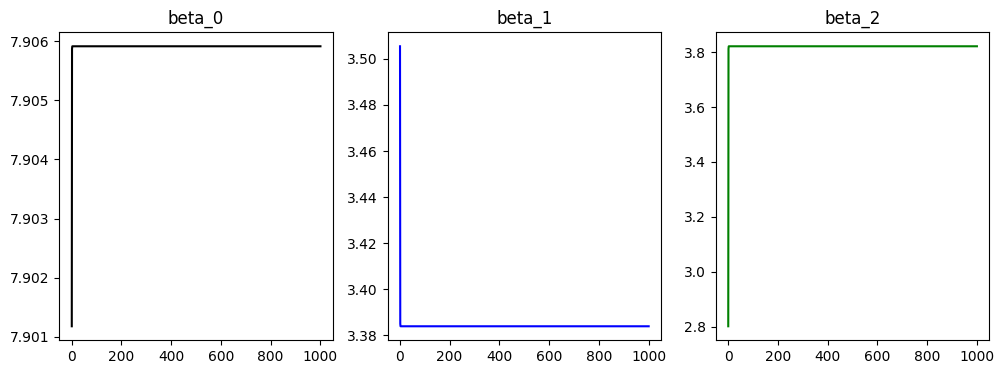

In [13]:
ax = subplots(1, 3, figsize=(12, 4))[1]
ax[0].plot(iteracoes, betas_0, c='k')
ax[0].set_title('beta_0')

ax[1].plot(iteracoes, betas_1, c='b')
ax[1].set_title('beta_1')

ax[2].plot(iteracoes, betas_2, c='g')
ax[2].set_title('beta_2')

(g) Compare your answer in (e) to the results of simply performing multiple linear regression to predict Y using X1 and X2.
Use axline() method to overlay those multiple linear regression
coefficient estimates on the plot obtained in (e).

In [14]:
X = pd.DataFrame({'x1':x1, 'x2':x2})
modelo_multivariado = OLS(y, ModelSpec(['x1','x2']).fit_transform(X)).fit()
modelo_multivariado.params

intercept    7.905913
x1           3.383865
x2           3.821351
dtype: float64

In [15]:
print('Real:\ny = 8 + 3.4 X1 + 3.8 X2 + ϵ\n')
print(f'Aproximação 1: \n{aproximacao_1}')
print(f'Aproximação 2: \n{aproximacao_2}')
print(f'Aproximação mínimo quadrado multivariado: \ny = {modelo_multivariado.params.iloc[0]} + {modelo_multivariado.params.iloc[1]} X1 + {modelo_multivariado.params.iloc[2]} X2')

Real:
y = 8 + 3.4 X1 + 3.8 X2 + ϵ

Aproximação 1: 
y = 7.901178156666939 + 3.505450616558508 X1 + 2.8011218204265207 X2
Aproximação 2: 
y = 7.90591301571982 + 3.383865157266199 X1 + 3.8213511576559513 X2
Aproximação mínimo quadrado multivariado: 
y = 7.905913015719818 + 3.3838651572661984 X1 + 3.821351157655951 X2


(h) On this data set, how many backfitting iterations were required
in order to obtain a “good” approximation to the multiple re
gression coefficient estimates?

In [16]:
betas_0[:8]

[np.float64(7.901178156666939),
 np.float64(7.905870735732196),
 np.float64(7.9059126381801),
 np.float64(7.905913012348574),
 np.float64(7.905913015689718),
 np.float64(7.905913015719548),
 np.float64(7.9059130157198165),
 np.float64(7.90591301571982)]

In [17]:
betas_1[:8]

[np.float64(3.505450616558508),
 np.float64(3.3849508562609625),
 np.float64(3.3838748520299813),
 np.float64(3.3838652438357224),
 np.float64(3.3838651580392227),
 np.float64(3.383865157273102),
 np.float64(3.383865157266259),
 np.float64(3.3838651572661993)]

In [18]:
betas_2[:8]

[np.float64(2.8011218204265207),
 np.float64(3.8122410060612992),
 np.float64(3.8212698084347037),
 np.float64(3.8213504312469855),
 np.float64(3.8213511511694733),
 np.float64(3.8213511575980292),
 np.float64(3.8213511576554335),
 np.float64(3.8213511576559465)]

Text(0.5, 1.0, 'beta_2')

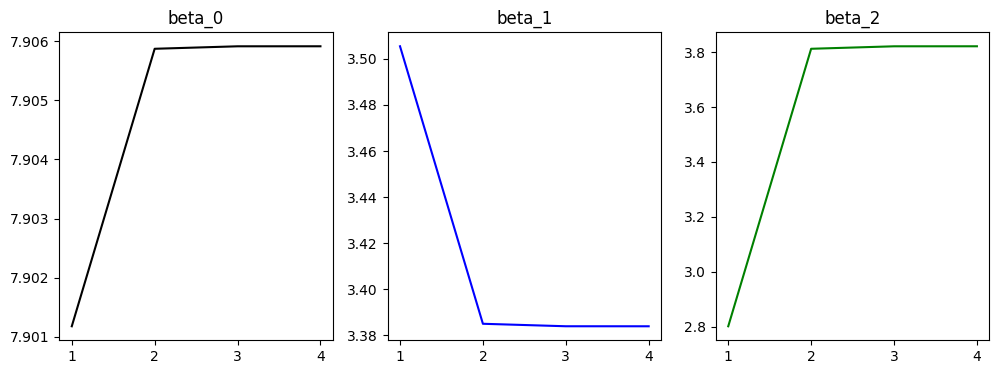

In [19]:
ax = subplots(1, 3, figsize=(12, 4))[1]
ax[0].plot(iteracoes[:4], betas_0[:4], c='k')
ax[0].set_title('beta_0')

ax[1].plot(iteracoes[:4], betas_1[:4], c='b')
ax[1].set_title('beta_1')

ax[2].plot(iteracoes[:4], betas_2[:4], c='g')
ax[2].set_title('beta_2')

# 12 #
This problem is a continuation of the previous exercise. In a toy
example with p = 100, show that one can approximate the multiple
linear regression coefficient estimates by repeatedly performing simple
linear regression in a backfitting procedure. How many backfitting
iterations are required in order to obtain a “good” approximation to
the multiple regression coefficient estimates? Create a plot to justify
your answer.

In [ ]:
n, p = 1000, 100
X_base = random.normal(0, 1, size=(n, p))
colunas = [f'x_{i}' for i in range(1,101)]
X = pd.DataFrame(X_base, columns= colunas)

beta_0_real = 8
betas_reais = random.normal(0, 3, size=p)
erro_natural = random.normal(0, 1.5, size=n)
y = beta_0_real + X @ betas_reais + erro_natural

betas_preditores = random.normal(0, 1, 100)
resultados_coeficientes = []
for i in range(0, 100):
    for j in range(p):
        # mais fácil calcular tudo depois remover o valor do preditor atual para ter o y parcial
        predicao_total = X @ betas_preditores
        y_parcial = y - (predicao_total - betas_preditores[j] * X.iloc[:,j])
        beta_0, betas_preditores[j] = simple_reg(y_parcial, X.iloc[:,j])
    resultado_rodada = [beta_0] + list(betas_preditores)
    resultados_coeficientes.append(resultado_rodada)

df_historico = pd.DataFrame(
    resultados_coeficientes, columns=['beta_0'] + colunas
)


In [55]:
df_historico.tail(1) - ([beta_0_real] + list(betas_reais))

,beta_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,...,x_91,x_92,x_93,x_94,x_95,x_96,x_97,x_98,x_99,x_100
99,-0.031907,0.042561,0.001222,0.00357,-0.000115,-0.041661,-0.036687,0.019527,-0.06362,-0.123606,...,0.040768,-0.052645,-0.061693,-0.09256,0.039425,0.088903,0.032574,0.02895,-0.018316,0.084037


In [56]:
df_historico.iloc[:15]

,beta_0,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,...,x_91,x_92,x_93,x_94,x_95,x_96,x_97,x_98,x_99,x_100
0,7.910477,3.177514,-3.170586,0.250065,-6.266313,0.285628,-4.096184,4.463566,-0.339085,0.242918,...,-0.100611,-2.769706,1.708227,-3.083075,-1.252534,4.955385,4.674783,-0.649012,0.031430,3.000398
1,7.958564,3.602874,-2.464586,-0.057128,-6.632419,0.005830,-5.452212,3.679105,0.189720,-0.521533,...,0.273361,-2.774244,2.128513,-2.822615,-1.864048,5.183235,4.881853,-0.716924,0.406327,3.203469
2,7.965711,3.428021,-2.445503,-0.158406,-6.598168,-0.087636,-5.263083,3.772982,0.202422,-0.444838,...,0.366601,-2.732865,2.162087,-2.785601,-1.952391,5.232140,4.901536,-0.711620,0.491403,3.265009
3,7.968409,3.423611,-2.438124,-0.209886,-6.614693,-0.121874,-5.200417,3.804577,0.216195,-0.394534,...,0.387132,-2.723415,2.176380,-2.782590,-1.967561,5.249085,4.900788,-0.699361,0.506002,3.274266
4,7.968239,3.424670,-2.441846,-0.228995,-6.627685,-0.132330,-5.189709,3.816711,0.222812,-0.384257,...,0.391263,-2.722840,2.180953,-2.782698,-1.970040,5.253833,4.899892,-0.695562,0.509081,3.275367
5,7.968138,3.425476,-2.443957,-0.234643,-6.631976,-0.135508,-5.186784,3.820535,0.224340,-0.382456,...,0.392146,-2.722949,2.182166,-2.782792,-1.970484,5.255229,4.899576,-0.694485,0.509923,3.275445
6,7.968107,3.425844,-2.444695,-0.236285,-6.633255,-0.136416,-5.185954,3.821593,0.224542,-0.382056,...,0.392350,-2.722969,2.182466,-2.782804,-1.970571,5.255650,4.899480,-0.694153,0.510180,3.275442
7,7.968097,3.425953,-2.444931,-0.236756,-6.633653,-0.136667,-5.185718,3.821890,0.224536,-0.381943,...,0.392398,-2.722966,2.182539,-2.782801,-1.970591,5.255776,4.899454,-0.694048,0.510258,3.275440
8,7.968094,3.425977,-2.445003,-0.236891,-6.633780,-0.136736,-5.185651,3.821975,0.224521,-0.381911,...,0.392410,-2.722962,2.182558,-2.782800,-1.970596,5.255813,4.899446,-0.694016,0.510282,3.275440
9,7.968093,3.425982,-2.445025,-0.236930,-6.633821,-0.136755,-5.185631,3.821999,0.224514,-0.381901,...,0.392413,-2.722961,2.182563,-2.782800,-1.970597,5.255824,4.899444,-0.694006,0.510289,3.275440


Text(0, 0.5, 'Coeficientes')

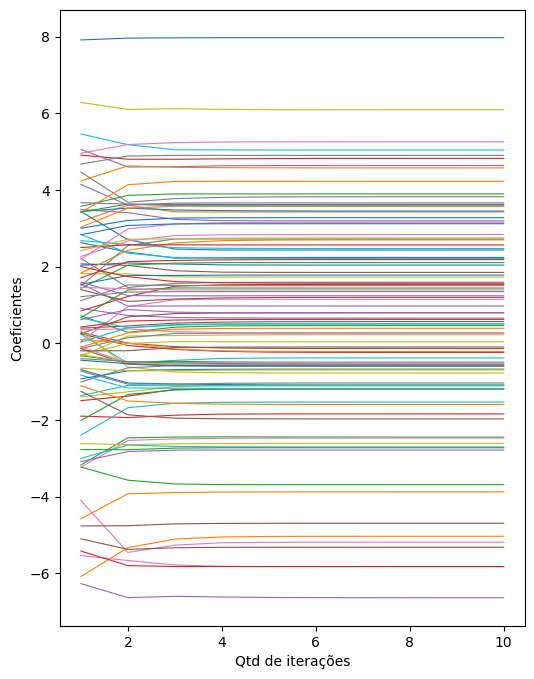

In [57]:
ax = subplots(figsize=(6,8))[1]
for coluna in df_historico.columns:
    ax.plot(range(1,11), df_historico[coluna].iloc[:10], linewidth=.8)
ax.set_xlabel('Qtd de iterações')
ax.set_ylabel('Coeficientes')